In [13]:
## Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

In [14]:
# Load the master NRI dataset
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")

# Filter data for Colorado and save to a new CSV
state_tracts_co = all_tracts[all_tracts["STATE"] == "Colorado"]
state_tracts_co.to_csv("Colorado_NRI.csv", index=False)

# Filter data for Minnesota and save to a new CSV
state_tracts_mn = all_tracts[all_tracts["STATE"] == "Minnesota"]
state_tracts_mn.to_csv("Minnesota_NRI.csv", index=False)

In [15]:
# Assign our datasets to variables
co_nri = pd.read_csv("Colorado_NRI.csv")
co_svi = pd.read_csv("Colorado.csv")

mn_nri = pd.read_csv("Minnesota_NRI.csv")
mn_svi = pd.read_csv("Minnesota.csv")

# Load the data dictionary for reference
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [16]:
# --- CLEANING CDC SVI DATA ---
# Replace CDC's placeholder for missing data (-999) with actual pandas missing values (NaN)
co_svi.replace(-999, np.nan, inplace=True)
mn_svi.replace(-999, np.nan, inplace=True)

# Drop tracts with zero population. 
# If nobody lives there (like a national park or airport), there is no social vulnerability.
co_svi = co_svi.dropna(subset=['E_TOTPOP']) 
co_svi = co_svi[co_svi['E_TOTPOP'] > 0]

mn_svi = mn_svi.dropna(subset=['E_TOTPOP']) 
mn_svi = mn_svi[mn_svi['E_TOTPOP'] > 0]

# --- CLEANING FEMA NRI DATA ---
# Fill structurally missing hazard data with 0.
# A missing Annual Loss or Frequency means the hazard does not physically occur there.
co_nri.fillna(0, inplace=True)
mn_nri.fillna(0, inplace=True)

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,40704,T27001770100,Minnesota,MN,27,Aitkin,County,1,27001,770100,...,49.000918,Relatively Moderate,0.000002,3.053379e-08,0.000006,86.023441,2935.157693,50.712013,Relatively Moderate,December 2025
1,40705,T27001770200,Minnesota,MN,27,Aitkin,County,1,27001,770200,...,46.289628,Relatively Low,0.000002,3.099227e-08,0.000006,84.094707,2790.207115,49.523934,Relatively Moderate,December 2025
2,40706,T27001770300,Minnesota,MN,27,Aitkin,County,1,27001,770300,...,55.810916,Relatively Moderate,0.000001,2.956724e-08,0.000006,85.249123,4316.009981,59.859147,Relatively Moderate,December 2025
3,40707,T27001770401,Minnesota,MN,27,Aitkin,County,1,27001,770401,...,39.787945,Relatively Low,0.000002,3.099193e-08,0.000006,86.721269,1706.702492,39.361512,Relatively Low,December 2025
4,40708,T27001770402,Minnesota,MN,27,Aitkin,County,1,27001,770402,...,40.423404,Relatively Low,0.000001,2.959116e-08,0.000006,85.649227,2018.396535,42.693376,Relatively Low,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,42201,T27171101300,Minnesota,MN,27,Wright,County,171,27171,101300,...,83.096802,Relatively High,0.000003,9.413526e-08,0.000006,79.021629,11341.960106,82.258660,Relatively High,December 2025
1498,42202,T27173970100,Minnesota,MN,27,Yellow Medicine,County,173,27173,970100,...,98.594930,Very High,0.000016,8.727441e-07,0.000009,80.507896,65612.128362,98.779747,Very High,December 2025
1499,42203,T27173970200,Minnesota,MN,27,Yellow Medicine,County,173,27173,970200,...,97.961825,Very High,0.000016,8.727449e-07,0.000009,81.971804,45196.168815,97.557110,Very High,December 2025
1500,42204,T27173970300,Minnesota,MN,27,Yellow Medicine,County,173,27173,970300,...,97.647626,Very High,0.000016,8.727449e-07,0.000009,79.353480,49162.374836,97.912223,Very High,December 2025


In [17]:
# Convert FIPS codes to strings so pandas doesn't accidentally delete leading zeros
co_nri['TRACTFIPS'] = co_nri['TRACTFIPS'].astype(str)
co_svi['FIPS'] = co_svi['FIPS'].astype(str)

mn_nri['TRACTFIPS'] = mn_nri['TRACTFIPS'].astype(str)
mn_svi['FIPS'] = mn_svi['FIPS'].astype(str)

# Join the NRI and SVI datasets together on the Census Tract FIPS codes
# 'inner' join ensures we only keep tracts that exist in both datasets
complete_data_co = pd.merge(co_nri, co_svi, left_on='TRACTFIPS', right_on='FIPS', how='inner')
complete_data_mn = pd.merge(mn_nri, mn_svi, left_on='TRACTFIPS', right_on='FIPS', how='inner')

print(f"Colorado tracts ready for analysis: {len(complete_data_co)}")
print(f"Minnesota tracts ready for analysis: {len(complete_data_mn)}")

Colorado tracts ready for analysis: 1437
Minnesota tracts ready for analysis: 1500


In [18]:
# --- CREATING THE NEW RISK DEFINITION AS DEFINED IN LEVELS OF RISK DOC ---

# EAL_SCORE: Expected Annual Loss composite score (NRI) 
# RPL_THEMES: Overall Social Vulnerability Percentile (CDC SVI)
# RESL_SCORE: Community Resilience Score (NRI)

eal_col = 'EAL_SCORE'   # Changed from 'EALT'
svi_col = 'RPL_THEMES'  
res_col = 'RESL_SCORE'  

def apply_multiplicative_risk(df):
    # 1. Normalize variables (Same as before)
    df['EAL_norm'] = (df[eal_col] - df[eal_col].min()) / (df[eal_col].max() - df[eal_col].min())
    df['SVI_norm'] = (df[svi_col] - df[svi_col].min()) / (df[svi_col].max() - df[svi_col].min())
    df['Resilience_norm'] = (df[res_col] - df[res_col].min()) / (df[res_col].max() - df[res_col].min())
    df['Lack_of_Resilience'] = 1 - df['Resilience_norm']
    
    # 2. Multiply instead of add. 
    # (We add a tiny number like 0.001 to prevent multiplying by literal zero)
    df['Custom_Risk_Raw'] = (df['EAL_norm'] + 0.001) * (df['SVI_norm'] + 0.001) * (df['Lack_of_Resilience'] + 0.001)
    
    # 3. Rank and convert to percentiles
    df['Proposed_Risk_Percentile'] = df['Custom_Risk_Raw'].rank(pct=True) * 100
    return df

# Apply the custom formula to both state datasets
complete_data_co = apply_custom_risk_formula(complete_data_co)
complete_data_mn = apply_custom_risk_formula(complete_data_mn)

# Display a preview comparing FEMA's Risk Percentile to your Proposed Risk Percentile
comparison_columns = ['TRACTFIPS', 'RISK_SPCTL', 'Proposed_Risk_Percentile']
print("Colorado Risk Comparison:")
display(complete_data_co[comparison_columns].head())

Colorado Risk Comparison:


C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1572903322.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['EAL_norm'] = (df[eal_col] - df[eal_col].min()) / (df[eal_col].max() - df[eal_col].min())
C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1572903322.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SVI_norm'] = (df[svi_col] - df[svi_col].min()) / (df[svi_col].max() - df[svi_col].min())
C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1572903322.py:15: PerformanceWarning: DataFrame is highly fragmente

,TRACTFIPS,RISK_SPCTL,Proposed_Risk_Percentile
0,8001007801,44.344951,67.784766
1,8001007802,37.570309,58.909853
2,8001007900,44.649376,72.117400
3,8001008000,27.625367,77.917540
4,8001008100,85.524360,94.129979


C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1675414504.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=county_risk.values, y=county_risk.index, palette='Reds_r')


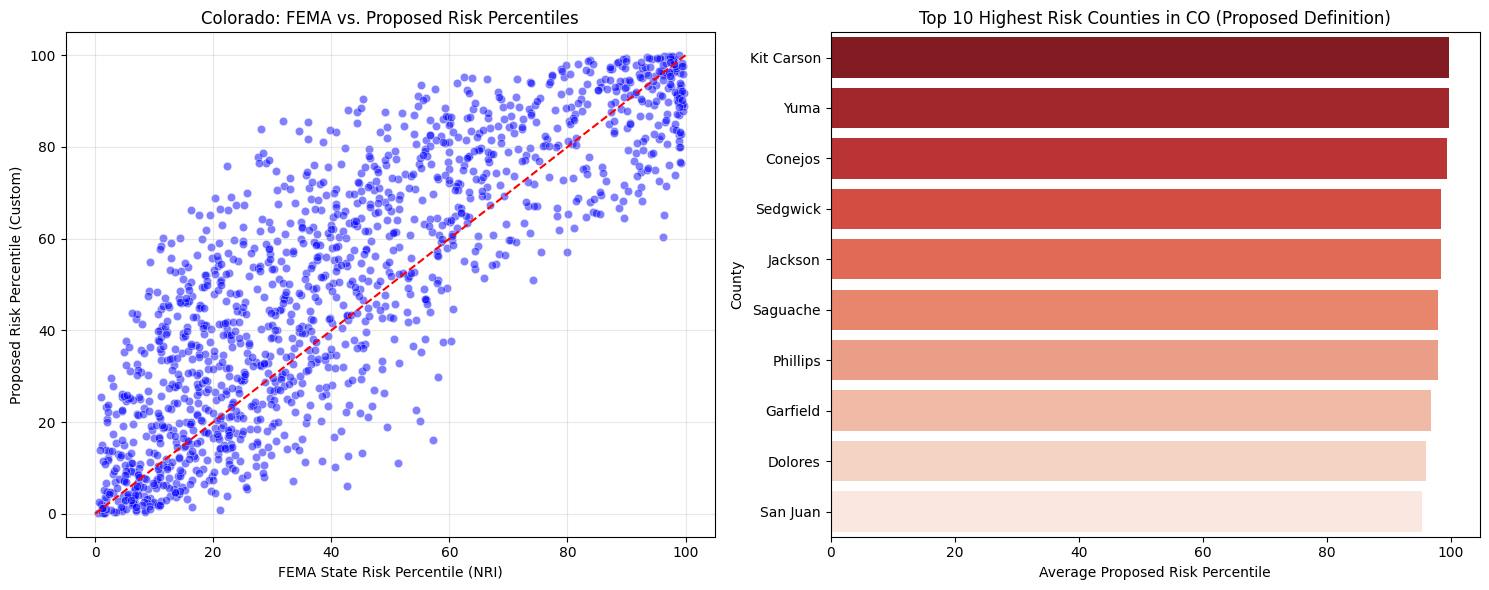

Census Tracts where the Proposed Model INCREASES risk the most compared to FEMA:


C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1675414504.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complete_data_co['Score_Difference'] = complete_data_co['Proposed_Risk_Percentile'] - complete_data_co['RISK_SPCTL']


,TRACTFIPS,COUNTY_x,RISK_SPCTL,Proposed_Risk_Percentile,Score_Difference
1217,8087000500,Morgan,28.039195,83.927324,55.888129
1190,8081000400,Moffat,31.793372,85.674354,53.880982
93,8001009603,Adams,22.337174,75.751223,53.414049
3,8001008000,Adams,27.625367,77.917540,50.292173
809,8041006000,El Paso,28.491075,78.616352,50.125277


In [19]:
# --- GENERATING SUMMARY FIGURES ---

plt.figure(figsize=(15, 6))

# Figure 1: Scatter plot showing how tracts shifted
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=complete_data_co, 
    x='RISK_SPCTL', 
    y='Proposed_Risk_Percentile', 
    alpha=0.5, 
    color='blue'
)
# Add a 1-to-1 line (if points fall on this line, FEMA and your model agree)
plt.plot([0, 100], [0, 100], color='red', linestyle='--')
plt.title('Colorado: FEMA vs. Proposed Risk Percentiles')
plt.xlabel('FEMA State Risk Percentile (NRI)')
plt.ylabel('Proposed Risk Percentile (Custom)')
plt.grid(True, alpha=0.3)

# Figure 2: Bar Chart showing the Top 10 most "At-Risk" Counties under your new definition
plt.subplot(1, 2, 2)
# Calculate average proposed risk by county
county_risk = complete_data_co.groupby('COUNTY_x')['Proposed_Risk_Percentile'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=county_risk.values, y=county_risk.index, palette='Reds_r')
plt.title('Top 10 Highest Risk Counties in CO (Proposed Definition)')
plt.xlabel('Average Proposed Risk Percentile')
plt.ylabel('County')

plt.tight_layout()
plt.show()

# Summary Table: Let's also print out a table of the tracts that shifted the MOST
complete_data_co['Score_Difference'] = complete_data_co['Proposed_Risk_Percentile'] - complete_data_co['RISK_SPCTL']
print("Census Tracts where the Proposed Model INCREASES risk the most compared to FEMA:")
display(complete_data_co[['TRACTFIPS', 'COUNTY_x', 'RISK_SPCTL', 'Proposed_Risk_Percentile', 'Score_Difference']].sort_values(by='Score_Difference', ascending=False).head(5))

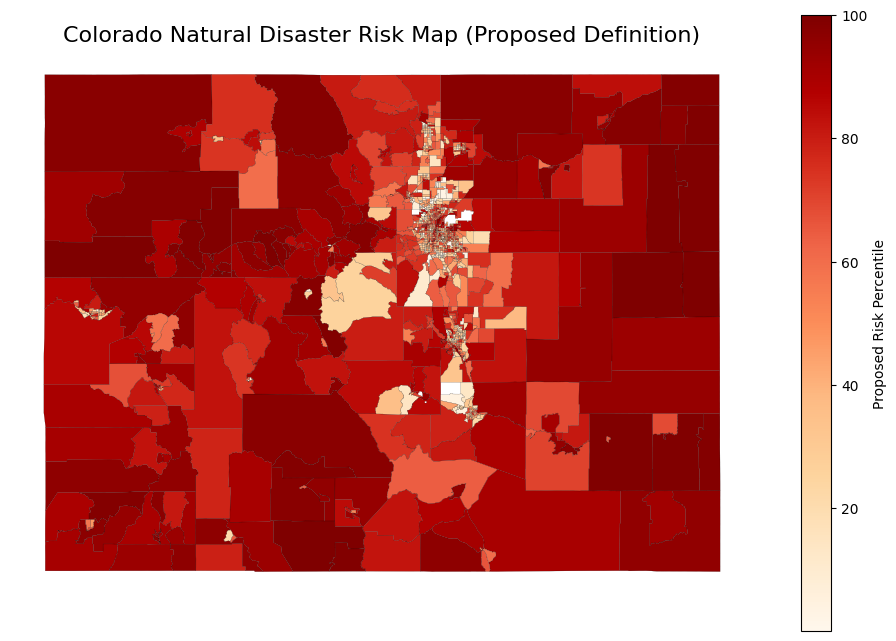

In [20]:
# --- GENERATING GEOPANDAS MAP ---

# 1. Load the shapefile for Colorado Census Tracts
co_shapefile_path = "tl_2025_08_tract.shp" 
co_map = gpd.read_file(co_shapefile_path)

# 2. Force the TRACTFIPS to be exactly 11 digits by adding leading zeros
complete_data_co['TRACTFIPS'] = complete_data_co['TRACTFIPS'].astype(str).str.zfill(11)

# 3. Merge the datasets
co_map_merged = co_map.merge(complete_data_co, left_on='GEOID', right_on='TRACTFIPS', how='inner')


# 4. Plot the Map!
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

co_map_merged.plot(
    column='Proposed_Risk_Percentile', 
    cmap='OrRd',           
    linewidth=0.1, 
    ax=ax, 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Proposed Risk Percentile", 'orientation': "vertical"}
)

plt.title("Colorado Natural Disaster Risk Map (Proposed Definition)", fontsize=16)
ax.axis('off') 
plt.show()

C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1994006389.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mn_county_risk.values, y=mn_county_risk.index, palette='Greens_r')


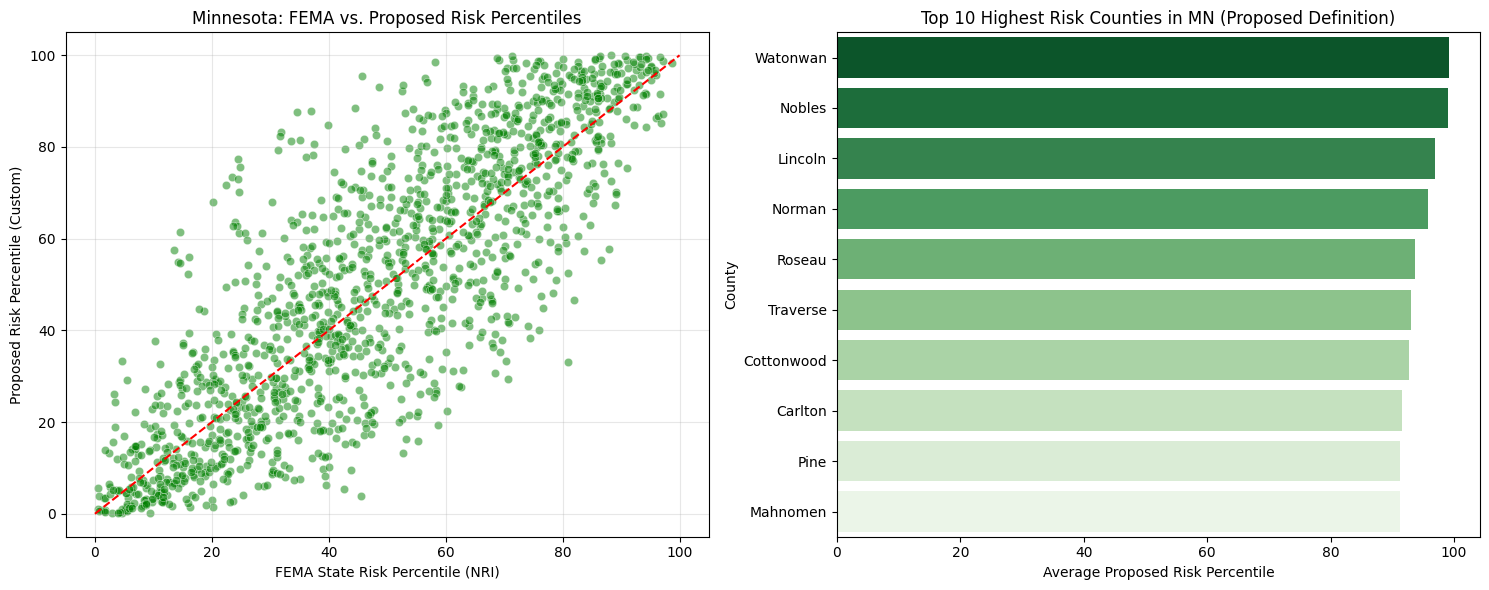

Minnesota Census Tracts where the Proposed Model INCREASES risk the most compared to FEMA:


C:\Users\Cameron\AppData\Local\Temp\ipykernel_2944\1994006389.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complete_data_mn['Score_Difference'] = complete_data_mn['Proposed_Risk_Percentile'] - complete_data_mn['RISK_SPCTL']


,TRACTFIPS,COUNTY_x,RISK_SPCTL,Proposed_Risk_Percentile,Score_Difference
1111,27123040902,Ramsey,34.521304,87.583445,53.062141
539,27053025201,Hennepin,24.500256,77.369826,52.869571
483,27053021300,Hennepin,31.884937,83.311081,51.426145
893,27099000200,Mower,36.907947,87.917223,51.009276
1057,27123034602,Ramsey,24.842734,75.567423,50.724690


In [21]:
# --- MINNESOTA: GENERATING SUMMARY FIGURES ---

plt.figure(figsize=(15, 6))

# Figure 1: Scatter plot showing how tracts shifted in MN
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=complete_data_mn, 
    x='RISK_SPCTL', 
    y='Proposed_Risk_Percentile', 
    alpha=0.5, 
    color='green' # Let's use green to easily distinguish it from CO!
)
plt.plot([0, 100], [0, 100], color='red', linestyle='--')
plt.title('Minnesota: FEMA vs. Proposed Risk Percentiles')
plt.xlabel('FEMA State Risk Percentile (NRI)')
plt.ylabel('Proposed Risk Percentile (Custom)')
plt.grid(True, alpha=0.3)

# Figure 2: Bar Chart showing the Top 10 most "At-Risk" Counties in MN
plt.subplot(1, 2, 2)
# Calculate average proposed risk by county
mn_county_risk = complete_data_mn.groupby('COUNTY_x')['Proposed_Risk_Percentile'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=mn_county_risk.values, y=mn_county_risk.index, palette='Greens_r')
plt.title('Top 10 Highest Risk Counties in MN (Proposed Definition)')
plt.xlabel('Average Proposed Risk Percentile')
plt.ylabel('County')

plt.tight_layout()
plt.show()

# Summary Table: Tracts that shifted the MOST
complete_data_mn['Score_Difference'] = complete_data_mn['Proposed_Risk_Percentile'] - complete_data_mn['RISK_SPCTL']
print("Minnesota Census Tracts where the Proposed Model INCREASES risk the most compared to FEMA:")
display(complete_data_mn[['TRACTFIPS', 'COUNTY_x', 'RISK_SPCTL', 'Proposed_Risk_Percentile', 'Score_Difference']].sort_values(by='Score_Difference', ascending=False).head(5))

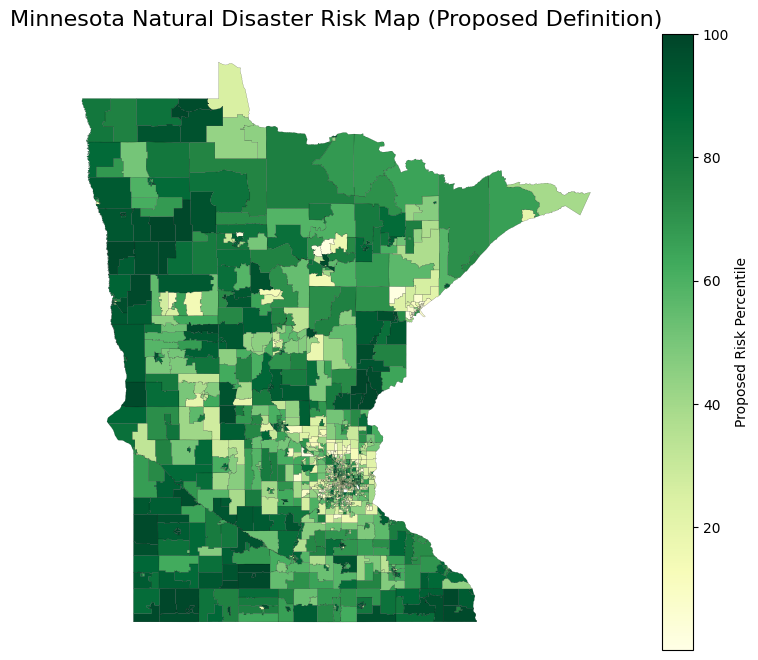

In [22]:
# --- MINNESOTA: GENERATING GEOPANDAS MAP ---

# 1. Load the shapefile for Minnesota Census Tracts (Using your absolute path!)
mn_shapefile_path = "tl_2025_27_tract.shp" 
mn_map = gpd.read_file(mn_shapefile_path)

# 2. FIX: Force the TRACTFIPS to be exactly 11 digits by adding leading zeros
complete_data_mn['TRACTFIPS'] = complete_data_mn['TRACTFIPS'].astype(str).str.zfill(11)

# 3. Merge the datasets
mn_map_merged = mn_map.merge(complete_data_mn, left_on='GEOID', right_on='TRACTFIPS', how='inner')


# 4. Plot the Map!
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mn_map_merged.plot(
    column='Proposed_Risk_Percentile', 
    cmap='YlGn',           # 'YlGn' = Yellow/Green color map for MN
    linewidth=0.1, 
    ax=ax, 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Proposed Risk Percentile", 'orientation': "vertical"}
)

plt.title("Minnesota Natural Disaster Risk Map (Proposed Definition)", fontsize=16)
ax.axis('off') 
plt.show()